# DAY 4 EXPLORATORY DATA ANALYSIS (EDA)
Bluestock Fintech Mutual Fund Analytics Capstone

In [45]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plotly is used for a few interactive charts
import plotly.express as px
import plotly.graph_objects as go

In [46]:
# Folder locations
RAW = "data/raw"
PROCESSED = "data/processed"
REPORTS = "reports"

# Create reports folder if it does not exist
os.makedirs(REPORTS, exist_ok=True)

# Make charts look cleaner
sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100


In [47]:
# Fund information
fund_master = pd.read_csv(
    "../data/raw/01_fund_master.csv"
)

# NAV history
nav_history = pd.read_csv(
    "../data/processed/nav_history_cleaned.csv"
)

# AUM by fund house
aum_by_house = pd.read_csv(
    "../data/raw/03_aum_by_fund_house.csv")

# Monthly SIP inflows
sip_inflows = pd.read_csv(
    "../data/raw/04_monthly_sip_inflows.csv"
)

# Category inflows
category_inflows = pd.read_csv(
    "../data/raw/05_category_inflows.csv"
)

# Industry folio count
folio_counts = pd.read_csv(
    "../data/raw/06_industry_folio_count.csv"
)

# Investor transactions
investor_txns = pd.read_csv(
    "../data/processed/investor_transactions_cleaned.csv"
)

# Portfolio holdings
portfolio_holdings = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

# Benchmark data
benchmark_idx = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

# Scheme performance
scheme_performance = pd.read_csv(
    "../data/processed/scheme_performance_cleaned.csv"
)

print("All files loaded successfully!")

All files loaded successfully!


In [48]:
print("Fund Master:", fund_master.shape)
print("NAV History:", nav_history.shape)
print("AUM:", aum_by_house.shape)
print("SIP:", sip_inflows.shape)
print("Category Inflows:", category_inflows.shape)
print("Folio Counts:", folio_counts.shape)
print("Investor Transactions:", investor_txns.shape)
print("Portfolio Holdings:", portfolio_holdings.shape)
print("Benchmark:", benchmark_idx.shape)
print("Scheme Performance:", scheme_performance.shape)


Fund Master: (40, 15)
NAV History: (46000, 3)
AUM: (90, 5)
SIP: (48, 6)
Category Inflows: (144, 3)
Folio Counts: (21, 6)
Investor Transactions: (32778, 13)
Portfolio Holdings: (322, 8)
Benchmark: (8050, 3)
Scheme Performance: (40, 19)


In [49]:
print("Fund Master columns:")
print(fund_master.columns.tolist())

print("\nNAV columns:")
print(nav_history.columns.tolist())

print("\nAUM columns:")
print(aum_by_house.columns.tolist())

print("\nSIP columns:")
print(sip_inflows.columns.tolist())

print("\nCategory Inflow columns:")
print(category_inflows.columns.tolist())

print("\nInvestor Transaction columns:")
print(investor_txns.columns.tolist())

print("\nPortfolio columns:")
print(portfolio_holdings.columns.tolist())

print("\nBenchmark columns:")
print(benchmark_idx.columns.tolist())


Fund Master columns:
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']

NAV columns:
['amfi_code', 'date', 'nav']

AUM columns:
['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']

SIP columns:
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']

Category Inflow columns:
['month', 'category', 'net_inflow_crore']

Investor Transaction columns:
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

Portfolio columns:
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']

Benchmark columns:
['date', 'index_name',

In [50]:
nav_history["date"] = pd.to_datetime(
    nav_history["date"]
)

sip_inflows["month"] = pd.to_datetime(
    sip_inflows["month"]
)

category_inflows["month"] = pd.to_datetime(
    category_inflows["month"]
)

folio_counts["month"] = pd.to_datetime(
    folio_counts["month"]
)

benchmark_idx["date"] = pd.to_datetime(
    benchmark_idx["date"]
)

print("Date columns converted!")

Date columns converted!


In [51]:
print("Fund Master")
display(fund_master.head())

print("NAV History")
display(nav_history.head())

print("Investor Transactions")
display(investor_txns.head())

Fund Master


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


NAV History


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


Investor Transactions


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


NAV TREND  FOR ALL FUNDS

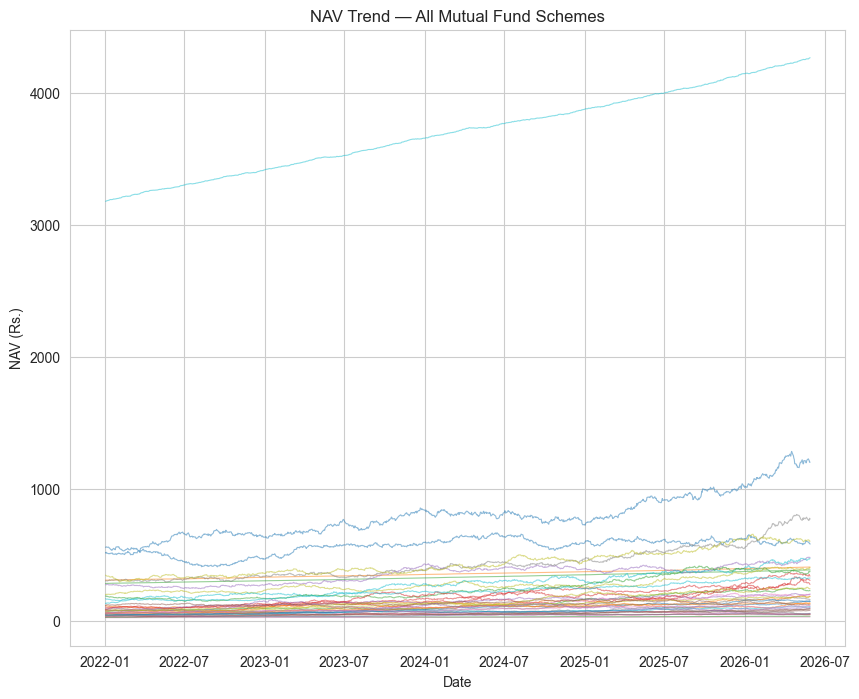

In [52]:
# Sort the data by date
nav_history = nav_history.sort_values("date")

plt.figure(figsize=(10, 8))

# Plot every fund separately
for fund_id in nav_history["amfi_code"].unique():

    fund_data = nav_history[
        nav_history["amfi_code"] == fund_id
    ]

    plt.plot(
        fund_data["date"],
        fund_data["nav"],
        linewidth=0.8,
        alpha=0.5
    )

plt.title("NAV Trend — All Mutual Fund Schemes")
plt.xlabel("Date")
plt.ylabel("NAV (Rs.)")

plt.show()

NAV TREND WITH IMPORTANT PERIODS

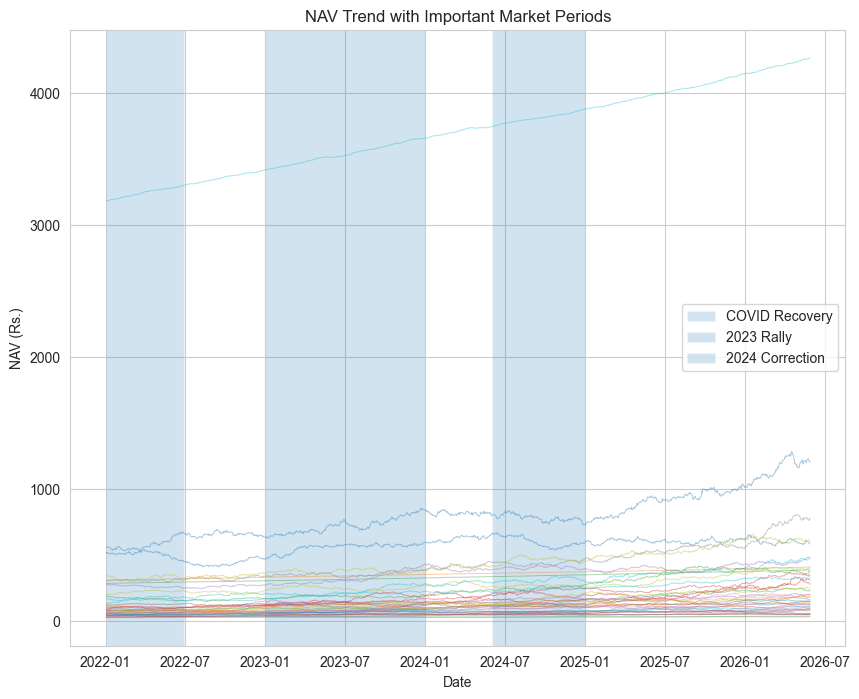

In [53]:
plt.figure(figsize=(10, 8))

for fund_id in nav_history["amfi_code"].unique():

    fund_data = nav_history[
        nav_history["amfi_code"] == fund_id
    ]

    plt.plot(
        fund_data["date"],
        fund_data["nav"],
        linewidth=0.7,
        alpha=0.4
    )

# Highlight 2022
plt.axvspan(
    pd.Timestamp("2022-01-01"),
    pd.Timestamp("2022-06-30"),
    alpha=0.2,
    label="COVID Recovery"
)

# Highlight 2023
plt.axvspan(
    pd.Timestamp("2023-01-01"),
    pd.Timestamp("2023-12-31"),
    alpha=0.2,
    label="2023 Rally"
)

# Highlight 2024
plt.axvspan(
    pd.Timestamp("2024-06-01"),
    pd.Timestamp("2024-12-31"),
    alpha=0.2,
    label="2024 Correction"
)

plt.title("NAV Trend with Important Market Periods")
plt.xlabel("Date")
plt.ylabel("NAV (Rs.)")

plt.legend()

plt.show()



In [54]:
plt.savefig(
    f"{REPORTS}/01_nav_trend_all_schemes.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

<Figure size 1200x600 with 0 Axes>

INTERACTIVE NAV CHART

In [55]:
fig = px.line(
    nav_history,
    x="date",
    y="nav",
    color="amfi_code",
    title="NAV Trend — Interactive"
)

fig.update_layout(
    height=600,
    showlegend=False
)

fig.show()


AUM BY FUND HOUSE

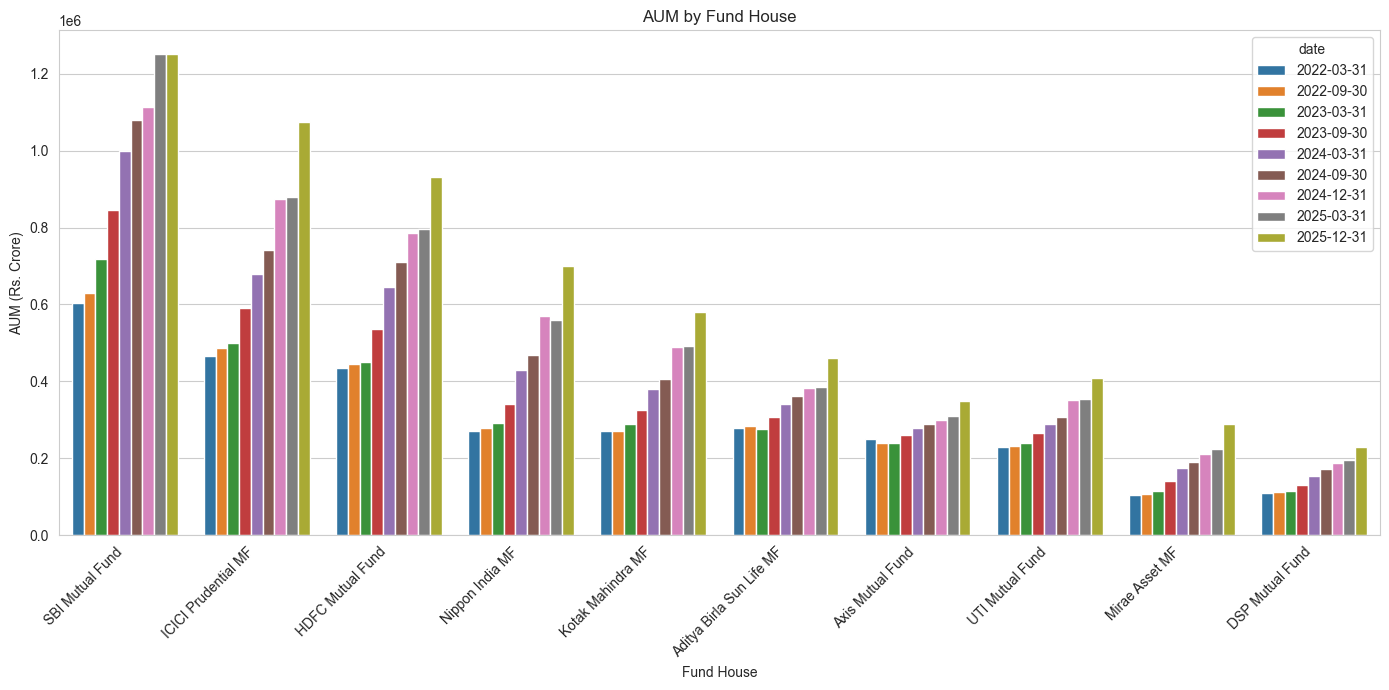

In [99]:
plt.figure(figsize=(14, 7))

sns.barplot(
    data=aum_by_house,
    x="fund_house",
    y="aum_crore",
    hue="date"
)

plt.title("AUM by Fund House")
plt.xlabel("Fund House")
plt.ylabel("AUM (Rs. Crore)")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    f"{REPORTS}/02_aum_growth_by_amc.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

HIGHLIGHT SBI

In [57]:
# Find SBI rows
sbi_data = aum_by_house[
    aum_by_house["fund_house"].str.contains(
        "SBI",
        case=False,
        na=False
    )
]

print("SBI AUM data:")
display(sbi_data)

SBI AUM data:


,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
10,2022-09-30,SBI Mutual Fund,6.30,630000,186
20,2023-03-31,SBI Mutual Fund,7.17,717000,186
30,2023-09-30,SBI Mutual Fund,8.45,845000,186
40,2024-03-31,SBI Mutual Fund,10.00,1000000,186
50,2024-09-30,SBI Mutual Fund,10.80,1080000,186
60,2024-12-31,SBI Mutual Fund,11.14,1114000,186
70,2025-03-31,SBI Mutual Fund,12.50,1250000,186
80,2025-12-31,SBI Mutual Fund,12.50,1250000,186


SAVING AUM CHART

MONTHLY SIP INFLOWS

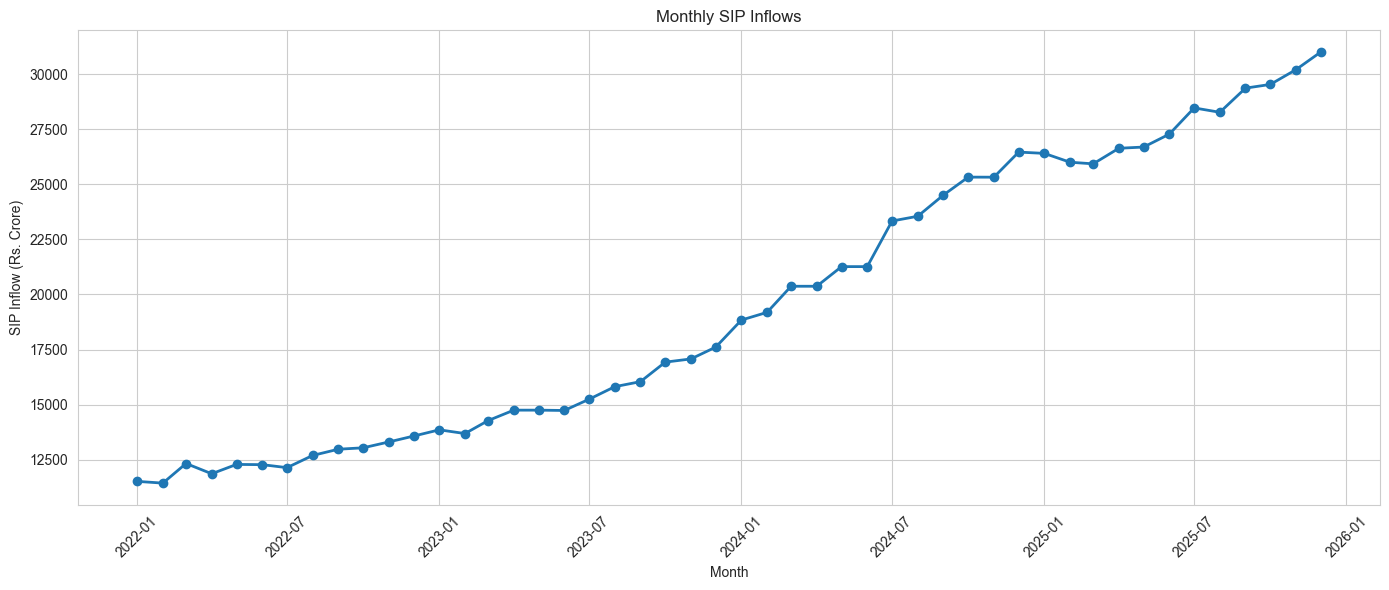

In [100]:
sip_inflows = sip_inflows.sort_values(
    "month"
)

plt.figure(figsize=(14, 6))

plt.plot(
    sip_inflows["month"],
    sip_inflows["sip_inflow_crore"],
    marker="o",
    linewidth=2
)

plt.title("Monthly SIP Inflows")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Rs. Crore)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    f"{REPORTS}/03_sip_inflow_trend.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [60]:
dec_2025 = sip_inflows[
    (sip_inflows["month"].dt.year == 2025) &
    (sip_inflows["month"].dt.month == 12)
]

print("December 2025 SIP data:")
display(dec_2025)

December 2025 SIP data:


,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
47,2025-12-01,31002,9.35,9.8,15.9,17.17


INTERACTIVE SIP CHART

In [61]:
fig = px.line(
    sip_inflows,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows",
    markers=True
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="SIP Inflow (Rs. Crore)"
)

fig.show()

CATEGORY-WISE INFLOW HEATMAP

In [63]:
# Create a month column
category_inflows["month_name"] = (
    category_inflows["month"]
    .dt.strftime("%Y-%m")
)

# Create a table:
# rows = categories
# columns = months
# values = net inflow

category_table = category_inflows.pivot_table(
    index="category",
    columns="month_name",
    values="net_inflow_crore",
    aggfunc="sum"
)

print("Category inflow table:")
display(category_table.head())

Category inflow table:


month_name,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


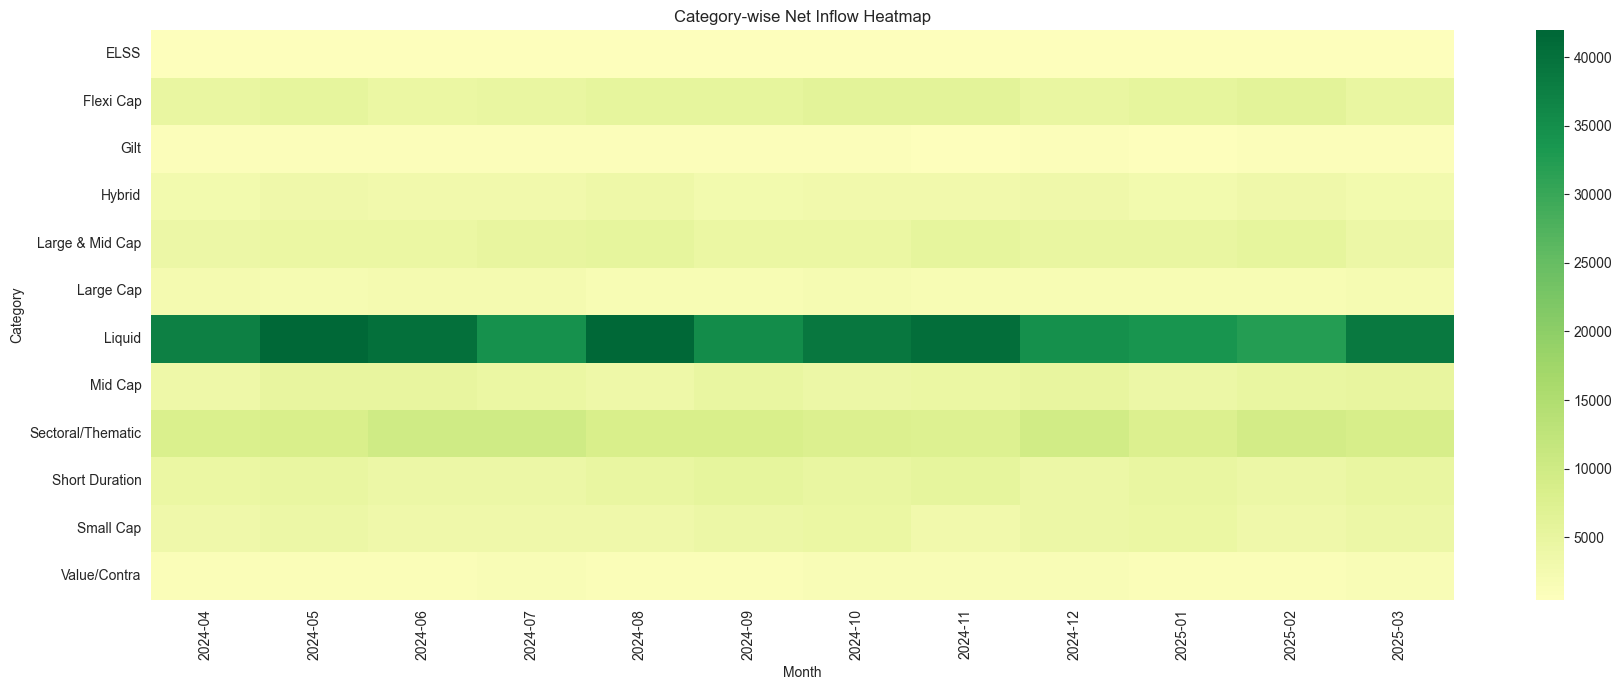

In [101]:
plt.figure(figsize=(18, 7))

sns.heatmap(
    category_table,
    cmap="RdYlGn",
    center=0
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(
    f"{REPORTS}/04_category_inflow_heatmap.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

INVESTOR AGE GROUP DISTRIBUTION

In [66]:

age_counts = investor_txns[
    "age_group"
].value_counts()

print(age_counts)

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64


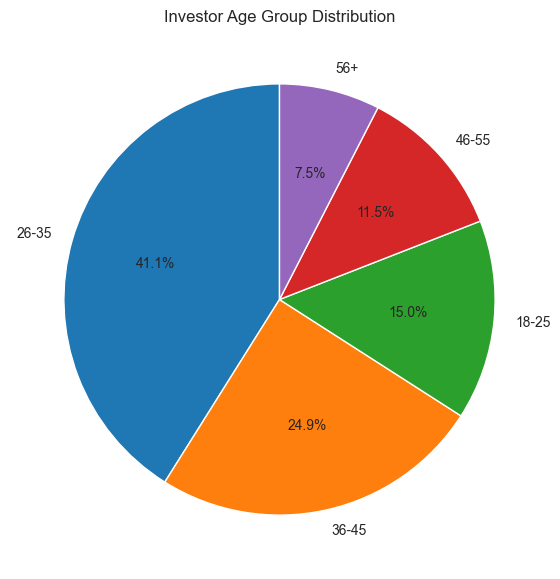

In [67]:
plt.figure(figsize=(7, 7))

plt.pie(
    age_counts.values,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.show()


SIP AMOUNT BY AGE GROUP

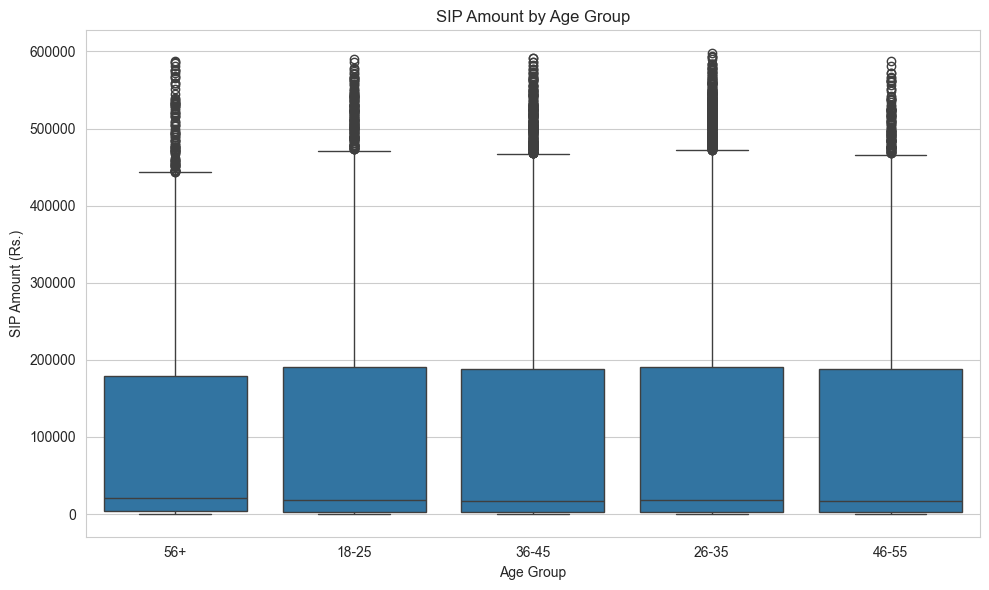

In [69]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=investor_txns,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (Rs.)")

plt.tight_layout()

plt.savefig(
    f"{REPORTS}/05_investor_demographics.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

SIP AMOUNT BY STATE

In [71]:
state_sip = (
    investor_txns
    .groupby("state")["amount_inr"]
    .sum()
)

state_sip = state_sip.sort_values()

print(state_sip)

state
Maharashtra       269513480
Karnataka         273753570
Haryana           279634354
Uttar Pradesh     285368873
Delhi             289633404
Telangana         290219284
West Bengal       297182514
Gujarat           298358940
Rajasthan         298645822
Madhya Pradesh    308312493
Tamil Nadu        315177237
Punjab            315780459
Name: amount_inr, dtype: int64


STATE-WISE HORIZONTAL BAR CHART

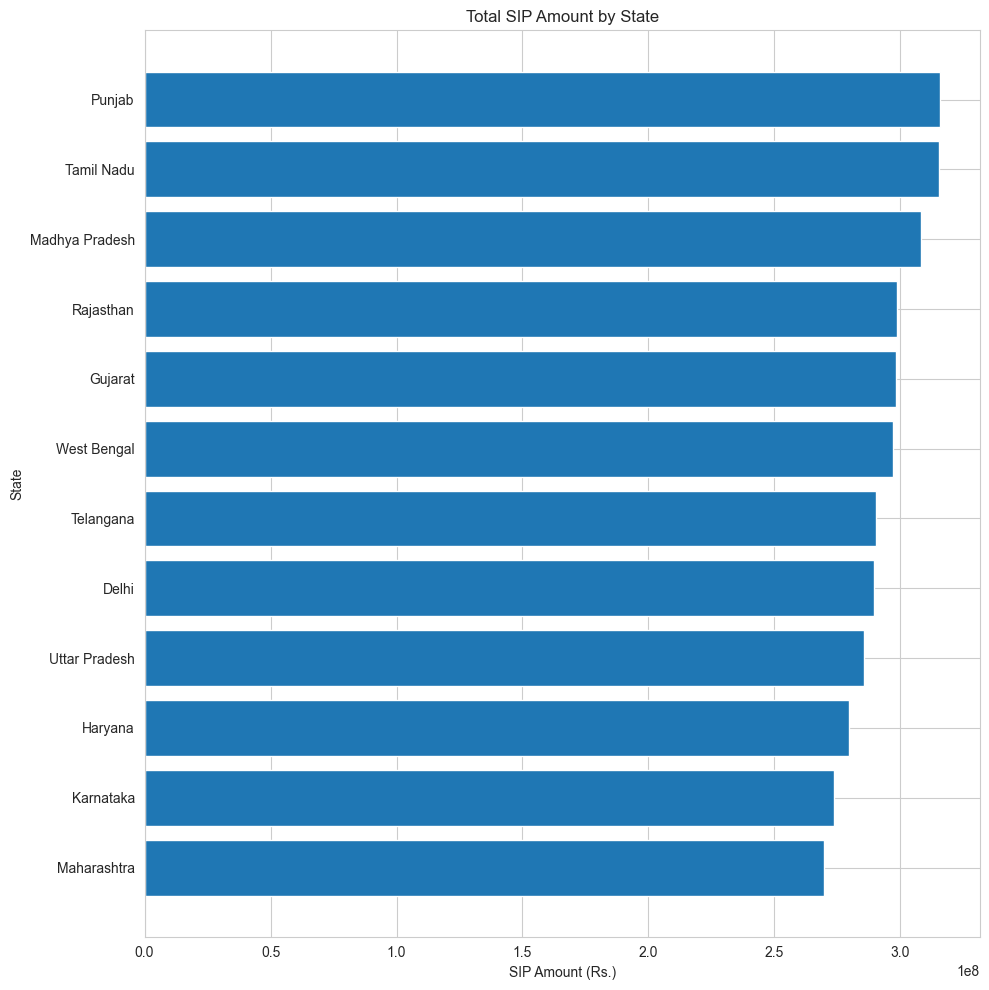

In [73]:
plt.figure(figsize=(10, 10))

plt.barh(
    state_sip.index,
    state_sip.values
)

plt.title("Total SIP Amount by State")
plt.xlabel("SIP Amount (Rs.)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    f"{REPORTS}/06a_sip_by_state.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

T30 VS B30

In [74]:
print(
    investor_txns.columns.tolist()
)

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


In [77]:
if "t30_b30" in investor_txns.columns:

    t30_b30 = investor_txns.groupby(
        "t30_b30"
    )["amount_inr"].sum()

else:

    print(
        "t30_b30 column not found."
    )

    print(
        "Using state-based approximation."
    )

    t30_states = [
        "Maharashtra",
        "Delhi",
        "Karnataka",
        "Tamil Nadu",
        "Gujarat",
        "West Bengal",
        "Telangana",
        "Uttar Pradesh",
        "Rajasthan",
        "Haryana",
        "Madhya Pradesh",
        "Andhra Pradesh",
        "Punjab",
        "Kerala"
    ]

    investor_txns["t30_b30"] = np.where(
        investor_txns["state"].isin(t30_states),
        "T30",
        "B30"
    )

    t30_b30 = investor_txns.groupby(
        "t30_b30"
    )["amount_inr"].sum()


print(t30_b30)



t30_b30
T30    3521580430
Name: amount_inr, dtype: int64


In [79]:
print(investor_txns["city_tier"].value_counts())

city_tier
T30    21719
B30    11059
Name: count, dtype: int64


In [80]:
print(investor_txns["state"].value_counts())

state
Punjab            2965
Madhya Pradesh    2931
Tamil Nadu        2806
Gujarat           2780
West Bengal       2748
Haryana           2736
Telangana         2718
Uttar Pradesh     2695
Delhi             2677
Karnataka         2621
Rajasthan         2577
Maharashtra       2524
Name: count, dtype: int64


In [81]:
print(investor_txns["t30_b30"].value_counts())

t30_b30
T30    32778
Name: count, dtype: int64


city_tier
B30     72304870
T30    144928621
Name: amount_inr, dtype: int64


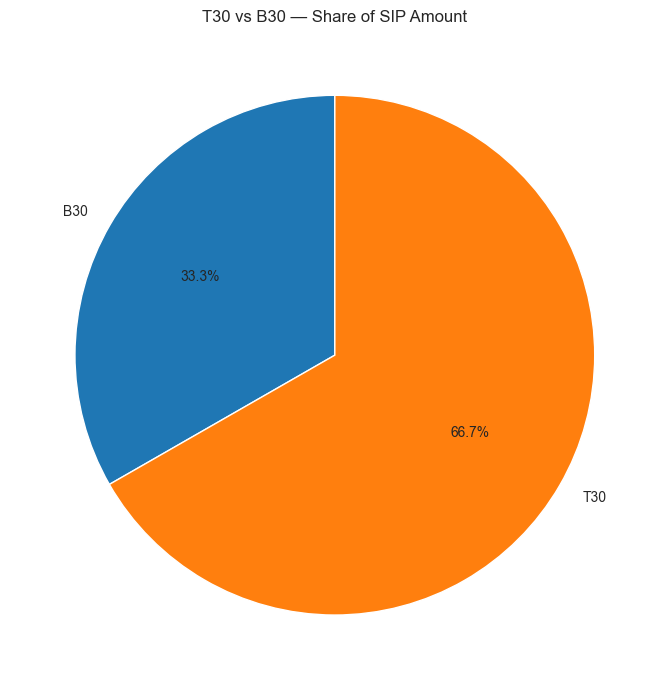

In [ ]:

# T30 vs B30 SHARE OF SIP AMOUNT

# Keeping only SIP transactions
sip_transactions = investor_txns[
    investor_txns["transaction_type"] == "SIP"
]

# Calculating total SIP amount for each city tier
t30_b30_amount = sip_transactions.groupby("city_tier")["amount_inr"].sum()

print(t30_b30_amount)

plt.figure(figsize=(7, 7))

plt.pie(
    t30_b30_amount.values,
    labels=t30_b30_amount.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 — Share of SIP Amount")

plt.tight_layout()

plt.show()

FOLIO COUNT GROWTH

 START AND END FOLIO COUNT

In [87]:
start_folio = folio_counts[
    "total_folios_crore"
].iloc[0]

end_folio = folio_counts[
    "total_folios_crore"
].iloc[-1]

print(
    "Starting folio count:",
    start_folio
)

print(
    "Ending folio count:",
    end_folio)

Starting folio count: 13.26
Ending folio count: 26.12


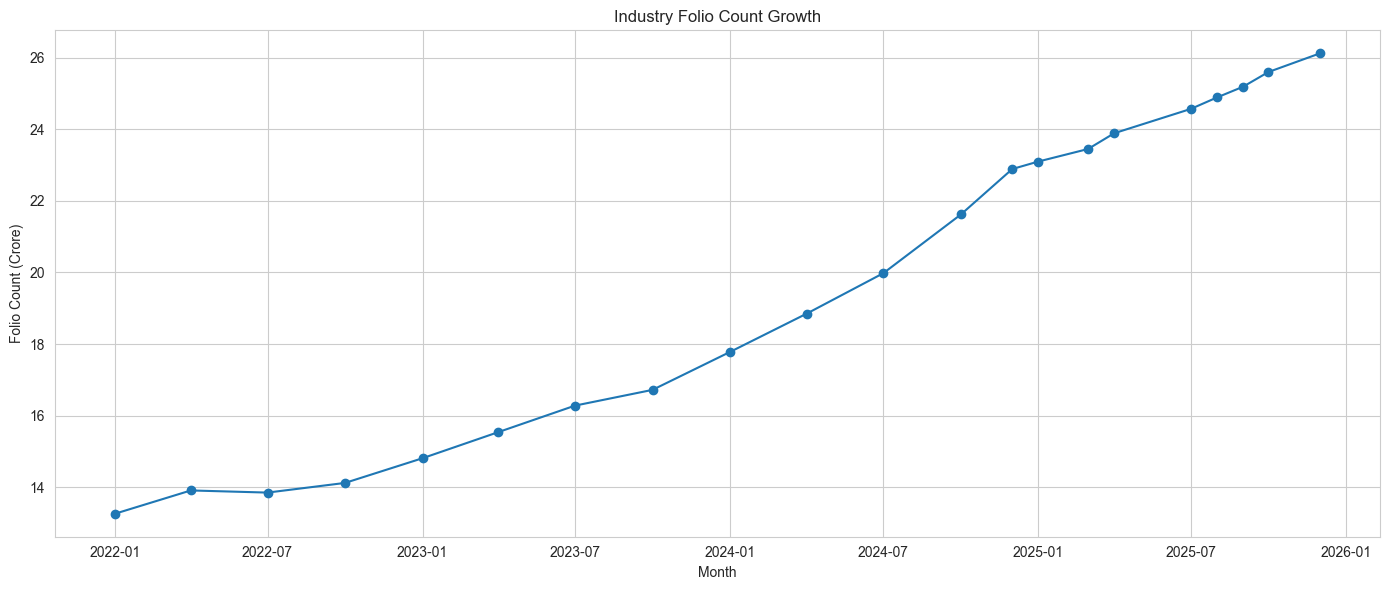

In [89]:
plt.figure(figsize=(14, 6))

plt.plot(
    folio_counts["month"],
    folio_counts["total_folios_crore"],
    marker="o"
)

plt.title("Industry Folio Count Growth")
plt.xlabel("Month")
plt.ylabel("Folio Count (Crore)")

plt.tight_layout()

plt.savefig(
    f"{REPORTS}/07_folio_count_growth.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [90]:
# Convert NAV data into:
# rows = dates
# columns = funds

nav_table = nav_history.pivot_table(
    index="date",
    columns="amfi_code",
    values="nav"
)

print(nav_table.head())

amfi_code     100016   100025    100033    101206   101207    101208   102885  \
date                                                                            
2022-01-03  520.4608  26.3169  107.3758  305.0996  38.5736  310.7415  89.8728   
2022-01-04  515.0971  26.2234  105.9447  305.4514  38.1545  310.6977  90.8724   
2022-01-05  521.7239  26.2221  105.4800  306.6324  38.1775  310.8165  90.1565   
2022-01-06  515.7880  26.1728  104.9350  305.9800  37.0665  310.7719  91.5338   
2022-01-07  515.1639  26.2261  104.3318  304.0480  37.9845  310.8388  90.6762   

amfi_code     102886    102887   118632  ...   120843     120844    125497  \
date                                     ...                                 
2022-01-03  119.2905  191.0721  42.8339  ...  49.9131  3180.6318  560.1443   
2022-01-04  120.6402  189.0737  42.8033  ...  50.8195  3181.4042  560.7052   
2022-01-05  121.4580  188.0701  43.0564  ...  50.1942  3182.8754  563.0884   
2022-01-06  125.2386  190.4545  43.2088  .

In [91]:
daily_returns = nav_table.pct_change()

print(
    daily_returns.head()
)

amfi_code     100016    100025    100033    101206    101207    101208  \
date                                                                     
2022-01-03       NaN       NaN       NaN       NaN       NaN       NaN   
2022-01-04 -0.010306 -0.003553 -0.013328  0.001153 -0.010865 -0.000141   
2022-01-05  0.012865 -0.000050 -0.004386  0.003866  0.000603  0.000382   
2022-01-06 -0.011377 -0.001880 -0.005167 -0.002128 -0.029101 -0.000143   
2022-01-07 -0.001210  0.002036 -0.005748 -0.006314  0.024766  0.000215   

amfi_code     102885    102886    102887    118632  ...    120843    120844  \
date                                                ...                       
2022-01-03       NaN       NaN       NaN       NaN  ...       NaN       NaN   
2022-01-04  0.011122  0.011314 -0.010459 -0.000714  ...  0.018160  0.000243   
2022-01-05 -0.007878  0.006779 -0.005308  0.005913  ... -0.012304  0.000462   
2022-01-06  0.015277  0.031127  0.012678  0.003540  ...  0.008509  0.000650   
2022-01

In [92]:

selected_funds = daily_returns.columns[:10]

print(
    "Selected funds:"
)

print(
    selected_funds
)

Selected funds:
Index([100016, 100025, 100033, 101206, 101207, 101208, 102885, 102886, 102887,
       118632],
      dtype='int64', name='amfi_code')


In [93]:
correlation = daily_returns[
    selected_funds
].corr()

print(correlation)


amfi_code    100016    100025    100033    101206    101207    101208  \
amfi_code                                                               
100016     1.000000  0.045567 -0.000006  0.027747  0.016053 -0.033773   
100025     0.045567  1.000000  0.002150  0.023769 -0.006710  0.018455   
100033    -0.000006  0.002150  1.000000 -0.018079  0.000351  0.007864   
101206     0.027747  0.023769 -0.018079  1.000000  0.010202 -0.027230   
101207     0.016053 -0.006710  0.000351  0.010202  1.000000 -0.007530   
101208    -0.033773  0.018455  0.007864 -0.027230 -0.007530  1.000000   
102885    -0.093533 -0.001038 -0.034228  0.001570 -0.005929 -0.001436   
102886    -0.005867  0.013754 -0.018166  0.007229  0.004860  0.014307   
102887    -0.023316 -0.005648 -0.036647 -0.006490  0.002304  0.036547   
118632    -0.026781 -0.014166 -0.013318 -0.005432  0.043384  0.003507   

amfi_code    102885    102886    102887    118632  
amfi_code                                          
100016    -0.093533

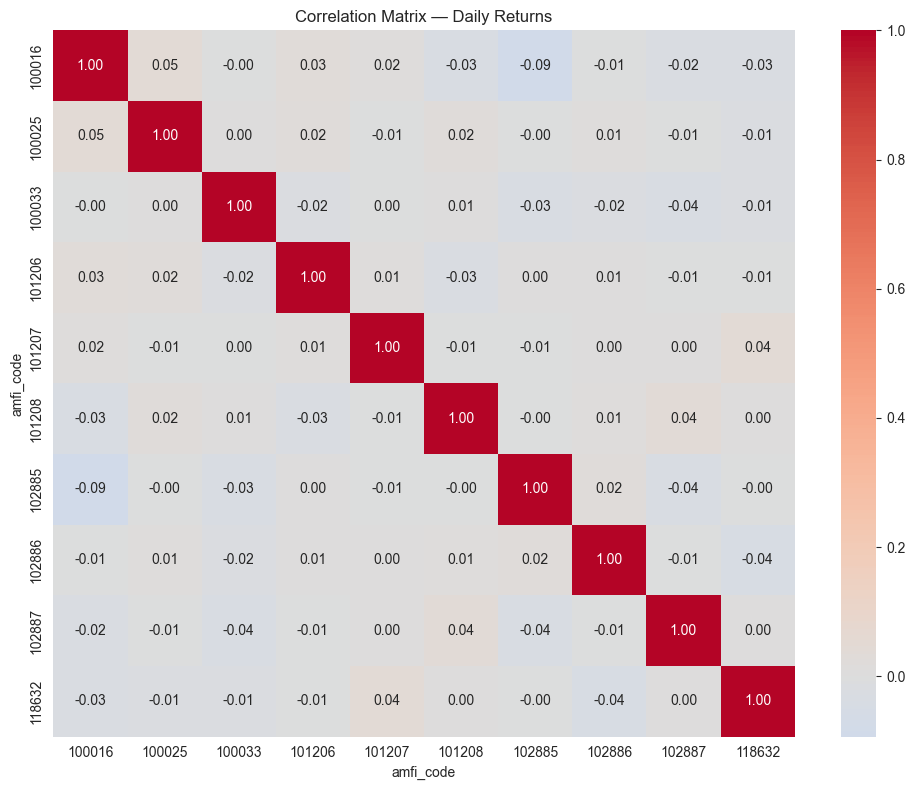

In [95]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Matrix — Daily Returns"
)

plt.tight_layout()

plt.savefig(
    f"{REPORTS}/08_correlation_matrix.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


SECTOR ALLOCATION

In [96]:
# Find equity funds
equity_funds = fund_master[
    fund_master["category"]
    .str.contains(
        "Equity",
        case=False,
        na=False
    )
]

# Get their AMFI codes
equity_ids = equity_funds[
    "amfi_code"
].tolist()

# Keep only equity fund holdings
equity_holdings = portfolio_holdings[
    portfolio_holdings["amfi_code"].isin(
        equity_ids
    )
]

print(
    equity_holdings.head()
)

   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  


In [97]:
sector_weights = (
    equity_holdings
    .groupby("sector")["weight_pct"]
    .sum()
)

sector_weights = sector_weights.sort_values(
    ascending=False
)

print(sector_weights)

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64


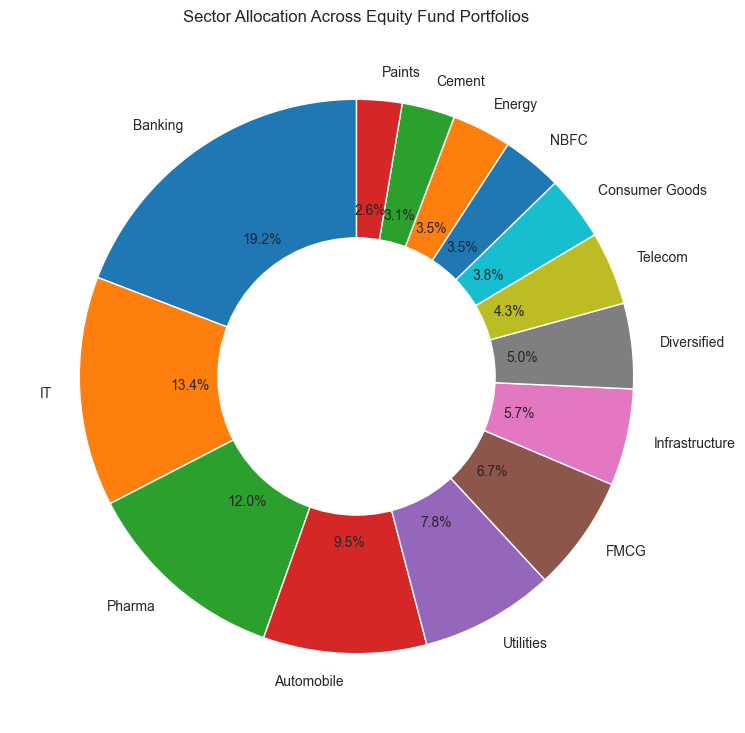

In [98]:
plt.figure(figsize=(9, 9))

plt.pie(
    sector_weights.values,
    labels=sector_weights.index,
    autopct="%1.1f%%",
    startangle=90
)

# Create the hole in the middle
circle = plt.Circle(
    (0, 0),
    0.5,
    color="white"
)

plt.gca().add_artist(circle)

plt.title(
    "Sector Allocation Across Equity Fund Portfolios"
)
plt.savefig(
    f"{REPORTS}/09_sector_allocation_donut.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()